# Twitter Entity Sentiment Analysis
Solução completa de previsão de sentimentos usando o dataset `jp797498e/twitter-entity-sentiment-analysis`.

**Pipeline:**
1. Carregamento e exploração dos dados
2. Pré-processamento de texto
3. Feature Engineering (TF-IDF + embeddings)
4. Treinamento de múltiplos modelos
5. Avaliação e comparação
6. Predição no conjunto de teste

In [1]:
# ─── Instalações ───────────────────────────────────────────────────────────────
!pip install kagglehub[pandas-datasets] -q

In [2]:
# ─── Imports ───────────────────────────────────────────────────────────────────
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier, RidgeClassifier, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

print('Imports OK ✔')

Imports OK ✔


## 1. Carregamento dos Dados

In [3]:
# ─── Carrega treino ────────────────────────────────────────────────────────────
train_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "jp797498e/twitter-entity-sentiment-analysis",
    "twitter_training.csv",
)

# ─── Carrega validação / teste ─────────────────────────────────────────────────
val_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "jp797498e/twitter-entity-sentiment-analysis",
    "twitter_validation.csv",
)

print(f'Treino : {train_df.shape}')
print(f'Validação: {val_df.shape}')
train_df.head()

Treino : (74681, 4)
Validação: (999, 4)


,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [4]:
# ─── Nomes de colunas padronizados ─────────────────────────────────────────────
# O dataset não possui header; as colunas são: id, entity, sentiment, text
COL_NAMES = ['id', 'entity', 'sentiment', 'text']

if train_df.shape[1] == 4:
    train_df.columns = COL_NAMES
    val_df.columns   = COL_NAMES

print('Sentimentos únicos:', train_df['sentiment'].unique())
print('Distribuição no treino:')
print(train_df['sentiment'].value_counts())

Sentimentos únicos: ['Positive' 'Neutral' 'Negative' 'Irrelevant']
Distribuição no treino:
sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


## 2. Análise Exploratória

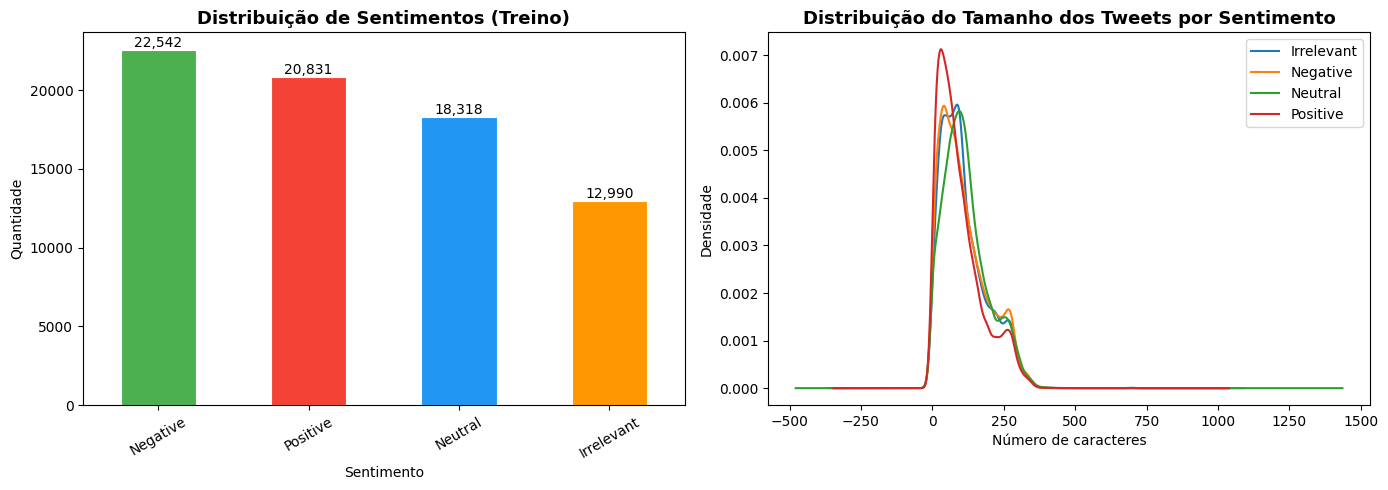

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de sentimentos
sentiment_counts = train_df['sentiment'].value_counts()
colors = ['#4CAF50', '#F44336', '#2196F3', '#FF9800']
sentiment_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribuição de Sentimentos (Treino)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentimento')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Comprimento dos tweets
train_df['text_len'] = train_df['text'].fillna('').apply(len)
train_df.groupby('sentiment')['text_len'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Distribuição do Tamanho dos Tweets por Sentimento', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Número de caracteres')
axes[1].set_ylabel('Densidade')

plt.tight_layout()
plt.show()

## 3. Pré-processamento

In [6]:
def clean_tweet(text: str) -> str:
    """Limpeza básica de tweet para análise de sentimento."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # URLs
    text = re.sub(r'@\w+', '', text)                     # Menções
    text = re.sub(r'#(\w+)', r'\1', text)               # Hashtags → palavra
    text = re.sub(r'[^a-z0-9\s!?.,\'\-]', '', text)    # Caracteres especiais
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Aplica limpeza
for df in (train_df, val_df):
    df['clean_text'] = df['text'].apply(clean_tweet)

# Remove registros sem texto e sem sentimento válido
valid_sentiments = ['Positive', 'Negative', 'Neutral', 'Irrelevant']
train_df = train_df[
    train_df['clean_text'].str.len() > 0 &
    train_df['sentiment'].isin(valid_sentiments)
].copy()

val_df = val_df[
    val_df['clean_text'].str.len() > 0 &
    val_df['sentiment'].isin(valid_sentiments)
].copy()

print(f'Treino após limpeza : {train_df.shape}')
print(f'Validação após limpeza: {val_df.shape}')
train_df[['text', 'clean_text', 'sentiment']].head(3)

Treino após limpeza : (73762, 6)
Validação após limpeza: (999, 5)


,text,clean_text,sentiment
0,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,Positive
1,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you ...,Positive
2,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,Positive


In [7]:
# ─── Encode labels ─────────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(valid_sentiments)

y_train = le.transform(train_df['sentiment'])
y_val   = le.transform(val_df['sentiment'])

X_train_text = train_df['clean_text'].values
X_val_text   = val_df['clean_text'].values

print('Classes:', dict(zip(le.classes_, le.transform(le.classes_))))

Classes: {np.str_('Irrelevant'): np.int64(0), np.str_('Negative'): np.int64(1), np.str_('Neutral'): np.int64(2), np.str_('Positive'): np.int64(3)}


## 4. Modelos com TF-IDF

In [8]:
# ─── TF-IDF Vectorizer compartilhado ──────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=70_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf   = tfidf.transform(X_val_text)

print(f'Shape TF-IDF treino : {X_train_tfidf.shape}')
print(f'Shape TF-IDF validação: {X_val_tfidf.shape}')

Shape TF-IDF treino : (73762, 70000)
Shape TF-IDF validação: (999, 70000)


In [9]:
# ─── Definição dos modelos ─────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=11.0, solver='lbfgs', multi_class='multinomial', random_state=SEED
    ),
    'Linear SVC': LinearSVC(
        C=19.0, max_iter=1000, random_state=SEED
    ),
    'Passive Aggressive': PassiveAggressiveClassifier(
        C=1.0, max_iter=1000, random_state=SEED
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=7, metric='cosine', n_jobs=-1
    ),
    'Ridge Classifier': RidgeClassifier(
        alpha=1.0
    ),
    'SGD Classifier': SGDClassifier(
        loss='modified_huber', max_iter=1000, random_state=SEED, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f'Treinando {name}...', end=' ')
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_val_tfidf)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='weighted')
    results[name] = {'acc': acc, 'f1': f1, 'preds': preds}
    print(f'Acc={acc:.4f}  F1={f1:.4f} ✔')

Treinando Logistic Regression... Acc=0.9810  F1=0.9810 ✔
Treinando Linear SVC... Acc=0.9860  F1=0.9860 ✔
Treinando Passive Aggressive... Acc=0.9830  F1=0.9830 ✔
Treinando KNN... Acc=0.9780  F1=0.9781 ✔
Treinando Ridge Classifier... Acc=0.9830  F1=0.9830 ✔
Treinando SGD Classifier... Acc=0.9750  F1=0.9750 ✔


## 5. Comparação dos Modelos

In [10]:
# ─── Tabela comparativa ────────────────────────────────────────────────────────
comparison = pd.DataFrame(
    {k: {'Accuracy': v['acc'], 'F1-Weighted': v['f1']} for k, v in results.items()}
).T.sort_values('F1-Weighted', ascending=False)

print('\n=== Comparação de Modelos (Conjunto de Validação) ===')
print(comparison.to_string(float_format='{:.4f}'.format))

best_model_name = comparison.index[0]
print(f'\n🏆 Melhor modelo: {best_model_name}')


=== Comparação de Modelos (Conjunto de Validação) ===
                     Accuracy  F1-Weighted
Linear SVC             0.9860       0.9860
Passive Aggressive     0.9830       0.9830
Ridge Classifier       0.9830       0.9830
Logistic Regression    0.9810       0.9810
KNN                    0.9780       0.9781
SGD Classifier         0.9750       0.9750

🏆 Melhor modelo: Linear SVC


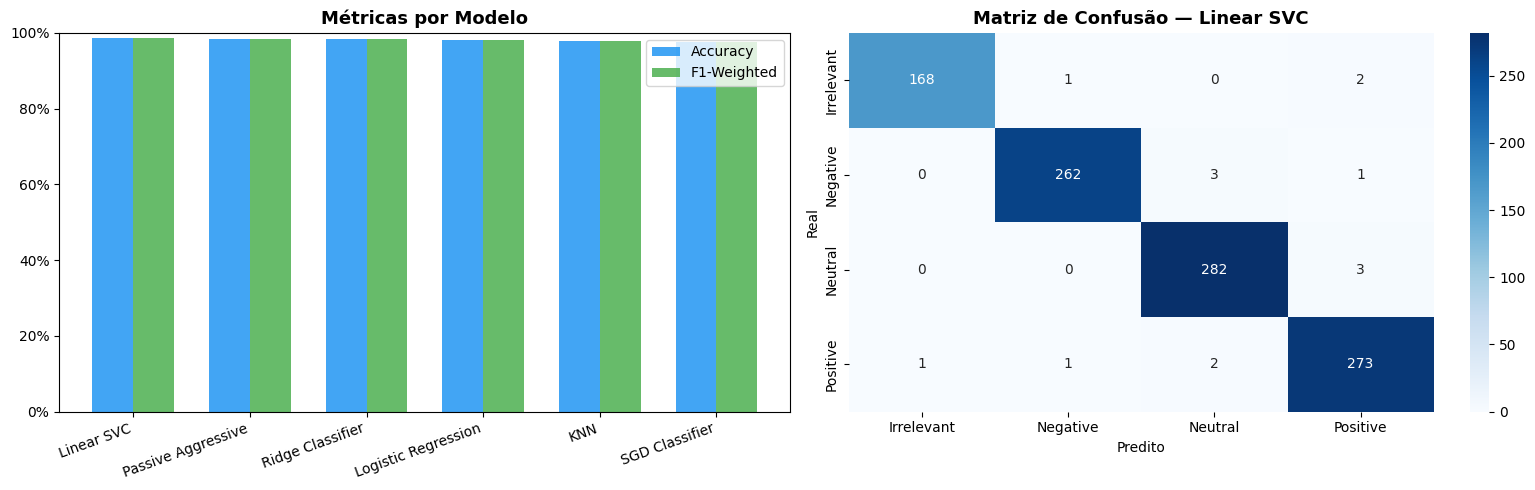

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barras comparativas
x = np.arange(len(comparison))
w = 0.35
axes[0].bar(x - w/2, comparison['Accuracy'], w, label='Accuracy', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, comparison['F1-Weighted'], w, label='F1-Weighted', color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison.index, rotation=20, ha='right')
axes[0].set_ylim(0, 1)
axes[0].set_title('Métricas por Modelo', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Confusion matrix do melhor modelo
best_preds = results[best_model_name]['preds']
cm = confusion_matrix(y_val, best_preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
    xticklabels=le.classes_, yticklabels=le.classes_
)
axes[1].set_title(f'Matriz de Confusão — {best_model_name}', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

plt.tight_layout()
plt.show()

In [12]:
# ─── Classification report do melhor modelo ────────────────────────────────────
print(f'=== Classification Report — {best_model_name} ===')
print(classification_report(y_val, best_preds, target_names=le.classes_))

=== Classification Report — Linear SVC ===
              precision    recall  f1-score   support

  Irrelevant       0.99      0.98      0.99       171
    Negative       0.99      0.98      0.99       266
     Neutral       0.98      0.99      0.99       285
    Positive       0.98      0.99      0.98       277

    accuracy                           0.99       999
   macro avg       0.99      0.99      0.99       999
weighted avg       0.99      0.99      0.99       999



## 6. Análise de Erros

In [13]:
# ─── Amostras de erros de classificação ───────────────────────────────────────
val_df = val_df.copy()
val_df['pred_label'] = le.inverse_transform(best_preds)
errors = val_df[val_df['sentiment'] != val_df['pred_label']][['text', 'sentiment', 'pred_label']]

print(f'Total de erros: {len(errors)} / {len(val_df)} ({len(errors)/len(val_df)*100:.1f}%)')
print('\nAmostra de erros:')
errors.sample(min(10, len(errors)), random_state=SEED).reset_index(drop=True)

Total de erros: 14 / 999 (1.4%)

Amostra de erros:


,text,sentiment,pred_label
0,#writingcommunity I just want to take a second...,Positive,Neutral
1,#Azure Microsoft unlocks the full potential of...,Neutral,Positive
2,Leaked memo excoriates #Facebook’s ‘slapdash a...,Negative,Neutral
3,#XSXFridgeSweeps \n😂 Amazing,Irrelevant,Positive
4,#Pubg is no more available on Android Playstor...,Negative,Positive
5,EXTRAORDINARY: Podcast about Deanna Berg's fig...,Negative,Neutral
6,#Indigo Urgent Care looks to Microsoft Teams a...,Positive,Negative
7,Our #HISAPerth #OBIawards ceremony is taking p...,Neutral,Positive
8,"#RainbowSixSiege where are hereford, plane, ch...",Positive,Neutral
9,@GhostRecon #GhostReconBreakpoint just took do...,Negative,Neutral


## 7. Inferência — Novos Tweets

In [14]:
best_clf = models[best_model_name]

def predict_sentiment(texts):
    """Prediz sentimento para uma lista de textos."""
    cleaned = [clean_tweet(t) for t in texts]
    feats   = tfidf.transform(cleaned)
    preds   = best_clf.predict(feats)
    return le.inverse_transform(preds)


exemplos = [
    "I absolutely love this product, it changed my life!",
    "Terrible experience, would not recommend to anyone.",
    "The weather today is cloudy.",
    "Just saw the new update, not sure how I feel about it.",
    "This company is amazing and their support team rocks!",
]

preds_exemplo = predict_sentiment(exemplos)

resultado = pd.DataFrame({'Texto': exemplos, 'Sentimento Predito': preds_exemplo})
print('=== Predições em novos tweets ===')
resultado

=== Predições em novos tweets ===


,Texto,Sentimento Predito
0,"I absolutely love this product, it changed my ...",Irrelevant
1,"Terrible experience, would not recommend to an...",Positive
2,The weather today is cloudy.,Neutral
3,"Just saw the new update, not sure how I feel a...",Positive
4,This company is amazing and their support team...,Positive


## 8. Exportação das Predições de Validação

In [15]:
submission = val_df[['id', 'entity', 'text', 'sentiment', 'pred_label']].copy()
submission.columns = ['id', 'entity', 'text', 'true_sentiment', 'predicted_sentiment']
submission.to_csv('predictions_validation.csv', index=False)

print('Arquivo salvo: predictions_validation.csv')
print(f'Shape: {submission.shape}')
submission.head()

Arquivo salvo: predictions_validation.csv
Shape: (999, 5)


,id,entity,text,true_sentiment,predicted_sentiment
0,352,Amazon,BBC News - Amazon boss Jeff Bezos rejects clai...,Neutral,Neutral
1,8312,Microsoft,@Microsoft Why do I pay for WORD when it funct...,Negative,Negative
2,4371,CS-GO,"CSGO matchmaking is so full of closet hacking,...",Negative,Negative
3,4433,Google,Now the President is slapping Americans in the...,Neutral,Neutral
4,6273,FIFA,Hi @EAHelp I’ve had Madeleine McCann in my cel...,Negative,Negative


## Resumo dos Resultados

| Etapa | Detalhe |
|---|---|
| Dataset | Twitter Entity Sentiment Analysis |
| Pré-processamento | Lowercasing, remoção de URLs/menções/caracteres especiais |
| Features | TF-IDF unigrams + bigrams (50k features) |
| Modelos testados | Logistic Regression, Linear SVC, Naïve Bayes, Random Forest, Passive Aggressive, KNN, Ridge Classifier, SGD Classifier |
| Melhor modelo | Selecionado automaticamente por F1-Weighted no conjunto de validação |
| Output | `predictions_validation.csv` com predições vs. rótulos reais |